# 生成 OLS 讲义中需要插入的图片

In [2]:
*-settings

global Lec "D:/github_lianxh/dsfin/Lecture"

global path "$Lec/reg_ols/fig"

cd $path

D:\github_lianxh\dsfin\Lecture\reg_ols\fig


In [ ]:

--- - --

&#x2753; 常数项的作用

<br>

$Y_{i}=\mathbf{1} {\color{red}{\alpha}} + X_{i} {\color{blue}{\beta}} + u_{i}$

$\bar{Y} = \mathbf{1} {\color{red}{\alpha}} + \bar{X} {\color{blue}{\beta}} + \bar{u}$

$\Longrightarrow$

$Y_{i} - \bar{Y} =  (X_{i}-\bar{X}) {\color{blue}{\beta}} + (u_{i}-\bar{u})$

![bg left:40% w:750](https://fig-lianxh.oss-cn-shenzhen.aliyuncs.com/FWL_DeConstant.png)


--- - --
### 常数项的作用
- $x$ 和 $y$ 的量纲不一致问题
- 吸收 $\small x$ 或 $\small y$ 的缩放 $(x \to x/c)$ 或平移 $(x \to x-c)$ 产生的影响，以保证统计推断 ($\small t$ 值不受影响) —— 后面会介绍 (或 [看看这个](https://finance.wharton.upenn.edu/~mrrobert/resources/Teaching/CorpFinPhD/Linear-Regression-Slides.pdf))

- 保证模型的 $\small R^2 \in [0,1]$，否则可能出现 $\small R^2<0$ 或 $\small R^2>1$ 的情况。
- 在 DID 和 RDD 分析中，常数项本身就有明确的经济含义

![](https://fig-lianxh.oss-cn-shenzhen.aliyuncs.com/Lianxh_装饰黄线.png)

Note: 平移 $(x \to x-c)$ 在 RDD 和交互项设定中非常必要，参见：

 - [交乘项的中心化问题](https://www.lianxh.cn/news/454644a5b7e3b.html) 
 - [Stata+R：一文读懂精确断点回归-RDD](https://www.lianxh.cn/news/96fb6b7e847e1.html)
 - [Stata：断点回归RDD简明教程](https://www.lianxh.cn/news/789f031b0c110.html)




In [6]:

*------------------
*- FWL: 常数项的作用和含义 
*------------------

*-产生模拟数据
  set scheme tufte  //lean1 绘图模板
  clear
  set obs 30
  set seed 13599
  gen x = 2*runiform() 
  gen e = 1*rnormal()
  gen y = 5 + 0.6*x + e
  save "sim_data_ols_constant.dta", replace
  


Number of observations (_N) was 0, now 30.
(file sim_data_ols_constant.dta not found)
file sim_data_ols_constant.dta saved


file FWL_NoConstant.png written in PNG format


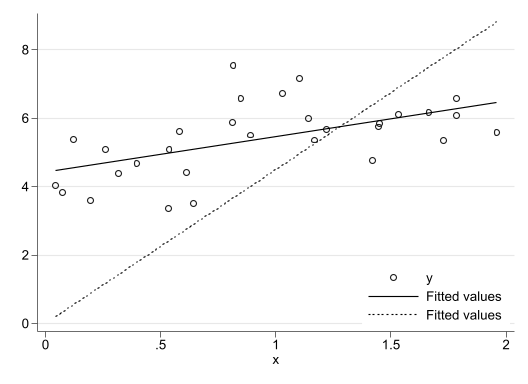

In [7]:

*-图示：不加常数项
  use "sim_data_ols_constant.dta", clear

  qui reg y x 
  qui predict yhat
  qui reg y x, noconstant
  qui predict yhat0
  
  #delimit ;
    tw (scatter y x)
       (lfit y  x, lp(solid))
       (lfit yhat0 x),
       legend(ring(0) pos(5) col(1));
  #delimit cr
  graph export "FWL_NoConstant.png", replace width(1200)




(file FWL_DeConstant.png not found)
file FWL_DeConstant.png written in PNG format


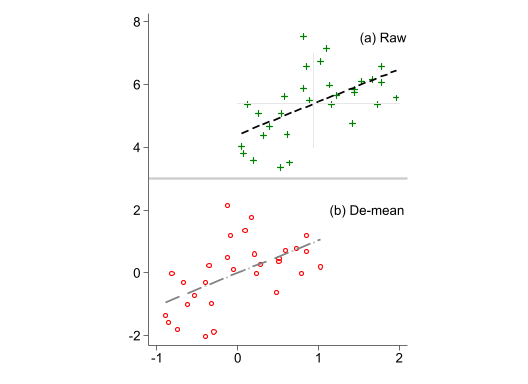

In [8]:

*-图示：常数项的作用-去均值

use "sim_data_ols_constant.dta", clear

  center y x, prefix(c_)  // De-mean
  
#delimit ;
  qui sum y; local ymean = r(mean);
  qui sum x; local xmean = r(mean);
  cap drop ?mean* ;
  gen  xmeanV = `xmean';
  egen ymeanV = seq(),from(4) to(7) ;
  gen  ymeanH = `ymean';  
  egen xmeanH = seq(),from(0) to(2) ;
  
  twoway 
    (scatter y x, mcolor(green) msymbol(+)) 
    (lfit      y   x, lcolor(black) lw(*1.5))   
    (scatter c_y c_x, mc(red)  ms(oh)) 
    (lfit    c_y c_x, lc(gray) lw(*1.5))
    (line ymeanV xmeanV, lc(gray*0.2) lw(*0.2))
    (line ymeanH xmeanH, lc(gray*0.2) lw(*0.2))
    ,
    xlabel(, nogrid) ylabel(,nogrid)
    yline(3, lc(black*0.2) lw(*2))
    text(7.5  1.8 "(a) Raw") 
    text(2.0  1.6 "(b) De-mean")
    legend(off) aspect(1.3) ;
#delimit cr
  graph export "FWL_DeConstant.png", replace width(1200)
